In [6]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
from IPython.display import display
import torch
from PIL import Image
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModelForDepthEstimation


In [7]:
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NOTEBOOK_ROOT = Path.cwd()
MOUNT_ROOT = Path('/media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde')
primary_foodsam = MOUNT_ROOT / 'FoodSAM_nutrition5k_outputs'

if primary_foodsam.exists():
    FOODSAM_OUTPUT_ROOT = primary_foodsam.resolve()
else:
    candidate_roots = [
        Path('data/FoodSAM_nutrition5k_outputs'),
        Path('../data/FoodSAM_nutrition5k_outputs'),
        Path('/data/FoodSAM_nutrition5k_outputs'),
        Path('FoodSAM_nutrition5k_outputs'),
        Path('../FoodSAM_nutrition5k_outputs'),
        Path('FoodSAM/nutrition5k_foodSAM_outputs'),
        Path('../FoodSAM/nutrition5k_foodSAM_outputs'),
        Path('FoodSAM/nutrition50_foodSAM_outputs'),
        Path('../FoodSAM/nutrition50_foodSAM_outputs'),
    ]
    for candidate in candidate_roots:
        if candidate.exists():
            FOODSAM_OUTPUT_ROOT = candidate.resolve()
            break
    else:
        raise FileNotFoundError('Could not locate FoodSAM outputs. Update `candidate_roots`.')

preferred_bases = [
    MOUNT_ROOT,
    FOODSAM_OUTPUT_ROOT.parent,
    FOODSAM_OUTPUT_ROOT.parent / 'data',
    Path('data'),
    Path('../data'),
    Path('/data'),
]

OUTPUT_BASE = None
for candidate in preferred_bases:
    candidate = Path(candidate)
    try:
        candidate.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        continue
    if candidate.exists() and candidate.is_dir():
        OUTPUT_BASE = candidate.resolve()
        break

if OUTPUT_BASE is None:
    raise PermissionError('No writable data directory found. Please update `preferred_bases`.')

ZOE_OUTPUT_ROOT = (OUTPUT_BASE / 'zoedepth_nutrition5k_outputs').resolve()
ZOE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"FoodSAM outputs: {FOODSAM_OUTPUT_ROOT}")
print(f"ZoeDepth outputs: {ZOE_OUTPUT_ROOT}")

TARGET_IMAGE_NAMES = ("pred_vis.png", "enhance_vis.png", "input.jpg")
SEED = 7
_ = torch.manual_seed(SEED)


FoodSAM outputs: /media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde/FoodSAM_nutrition5k_outputs
ZoeDepth outputs: /media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde/zoedepth_nutrition5k_outputs


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained("Intel/zoedepth-nyu-kitti")
model = AutoModelForDepthEstimation.from_pretrained(
    "Intel/zoedepth-nyu-kitti",
    torch_dtype=torch.float32,
).to(device).eval()

print(f"Loaded ZoeDepth on {device}.")


Loaded ZoeDepth on cuda.


In [9]:
def pick_source_image(dish_dir: Path) -> Path | None:
    for name in TARGET_IMAGE_NAMES:
        candidate = dish_dir / name
        if candidate.exists():
            return candidate
    return None


def predict_depth_map(image_path: Path) -> np.ndarray:
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        depth = outputs.predicted_depth  # (1, H, W)
        depth = torch.nn.functional.interpolate(
            depth.unsqueeze(1),
            size=image.size[::-1],
            mode="bicubic",
            align_corners=False,
        )
        depth = depth.squeeze().cpu().numpy().astype(np.float32)

    return depth


def depth_to_colormap(depth: np.ndarray) -> Image.Image:
    finite_depth = depth[np.isfinite(depth)]
    if finite_depth.size == 0:
        raise ValueError("Depth map contains no finite values")

    lo = np.percentile(finite_depth, 2.0)
    hi = np.percentile(finite_depth, 98.0)
    if np.isclose(hi, lo):
        normalized = np.zeros_like(depth, dtype=np.float32)
    else:
        clipped = np.clip(depth, lo, hi)
        normalized = (clipped - lo) / (hi - lo)

    colormap = cm.magma(normalized)
    rgb = (colormap[..., :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb)


In [10]:
summary_path = ZOE_OUTPUT_ROOT / "summary.csv"
existing_summary_df = None
processed_dishes = set()
if summary_path.exists():
    try:
        existing_summary_df = pd.read_csv(summary_path)
        processed_dishes = set(existing_summary_df["dish_id"].astype(str).tolist())
        print(f"Loaded existing summary with {len(processed_dishes)} dishes.")
    except Exception as exc:
        print(f"Failed to load existing summary: {exc}. Rebuilding from scratch.")
        existing_summary_df = None
        processed_dishes = set()

records: List[Dict[str, object]] = []

for dish_dir in tqdm(sorted(FOODSAM_OUTPUT_ROOT.glob("dish_*")), desc="Dishes"):
    if not dish_dir.is_dir():
        continue

    source_image = pick_source_image(dish_dir)
    if source_image is None:
        print(f"No candidate image found for {dish_dir.name}, skipping.")
        continue

    dish_output_dir = ZOE_OUTPUT_ROOT / dish_dir.name
    dish_output_dir.mkdir(parents=True, exist_ok=True)

    depth_basename = source_image.stem + "_zoedepth"
    depth_npy_path = dish_output_dir / f"{depth_basename}.npy"
    depth_png_path = dish_output_dir / f"{depth_basename}.png"

    if (
        dish_dir.name in processed_dishes
        and depth_npy_path.exists()
        and depth_png_path.exists()
    ):
        continue

    depth = predict_depth_map(source_image)
    depth_vis = depth_to_colormap(depth)

    np.save(depth_npy_path, depth)
    depth_vis.save(depth_png_path)

    records.append(
        {
            "dish_id": dish_dir.name,
            "source_image": source_image.relative_to(FOODSAM_OUTPUT_ROOT).as_posix(),
            "depth_npy": depth_npy_path.relative_to(ZOE_OUTPUT_ROOT).as_posix(),
            "depth_vis": depth_png_path.relative_to(ZOE_OUTPUT_ROOT).as_posix(),
            "depth_min": float(np.nanmin(depth)),
            "depth_max": float(np.nanmax(depth)),
        }
    )

print(f"Processed {len(records)} dishes in this run.")


Dishes:   0%|          | 0/3490 [00:00<?, ?it/s]

Processed 3490 dishes in this run.


In [11]:
new_df = pd.DataFrame.from_records(records)
if existing_summary_df is not None and not existing_summary_df.empty:
    summary_df = pd.concat([existing_summary_df, new_df], ignore_index=True)
    summary_df = summary_df.drop_duplicates(subset=["dish_id"], keep="last")
else:
    summary_df = new_df

summary_df = summary_df.sort_values("dish_id").reset_index(drop=True)
summary_path = ZOE_OUTPUT_ROOT / "summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Summary contains {len(summary_df)} dishes and was written to: {summary_path}")
display(summary_df.head())


Summary contains 3490 dishes and was written to: /media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde/zoedepth_nutrition5k_outputs/summary.csv


,dish_id,source_image,depth_npy,depth_vis,depth_min,depth_max
0,dish_1556572657,dish_1556572657/pred_vis.png,dish_1556572657/pred_vis_zoedepth.npy,dish_1556572657/pred_vis_zoedepth.png,0.879303,1.579113
1,dish_1556573514,dish_1556573514/pred_vis.png,dish_1556573514/pred_vis_zoedepth.npy,dish_1556573514/pred_vis_zoedepth.png,0.846356,1.553235
2,dish_1556575014,dish_1556575014/pred_vis.png,dish_1556575014/pred_vis_zoedepth.npy,dish_1556575014/pred_vis_zoedepth.png,0.833743,1.535177
3,dish_1556575083,dish_1556575083/pred_vis.png,dish_1556575083/pred_vis_zoedepth.npy,dish_1556575083/pred_vis_zoedepth.png,0.851530,1.482449
4,dish_1556575124,dish_1556575124/pred_vis.png,dish_1556575124/pred_vis_zoedepth.npy,dish_1556575124/pred_vis_zoedepth.png,0.868513,1.980973


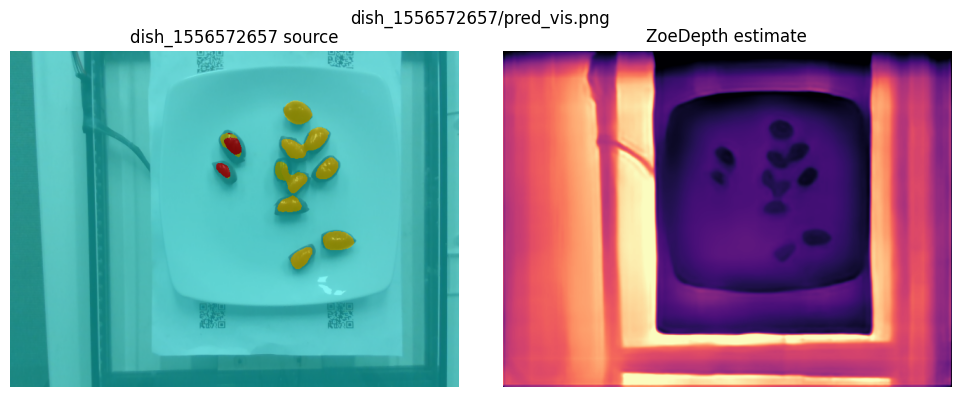

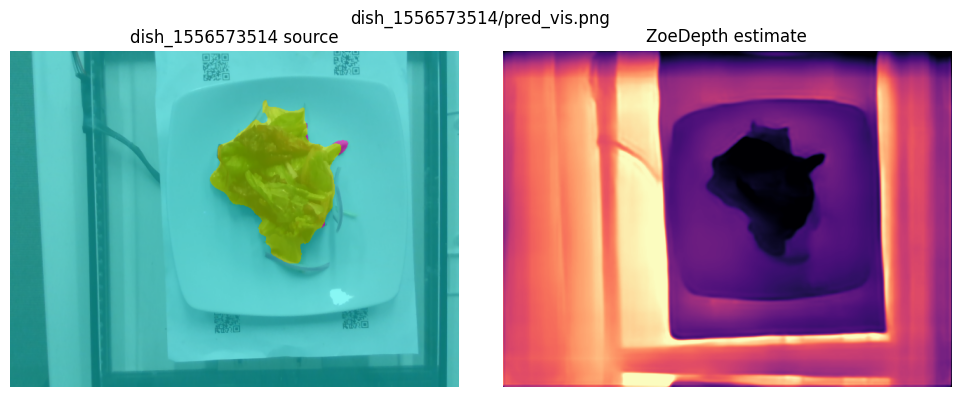

In [12]:
NUM_SAMPLES = 2
sample_df = summary_df.head(NUM_SAMPLES)

for _, row in sample_df.iterrows():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    src_path = FOODSAM_OUTPUT_ROOT / row["source_image"]
    depth_vis_path = ZOE_OUTPUT_ROOT / row["depth_vis"]

    axes[0].imshow(Image.open(src_path))
    axes[0].set_title(f"{row['dish_id']} source")
    axes[0].axis("off")

    axes[1].imshow(Image.open(depth_vis_path))
    axes[1].set_title("ZoeDepth estimate")
    axes[1].axis("off")

    fig.suptitle(row["source_image"])
    plt.tight_layout()
    plt.show()


In [13]:
# FoodSAM summarization helpers
import csv
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

BACKGROUND_CATEGORY_IDS = {"0"}
BACKGROUND_CATEGORY_NAMES = {"background"}


@dataclass
class FoodItemSummary:
    """Aggregate statistics for a single food label."""

    label: str
    count: int
    mask_ratio_sum: float

    @property
    def mask_ratio_mean(self) -> float:
        if self.count == 0:
            return 0.0
        return self.mask_ratio_sum / self.count

    def to_serializable(self) -> Dict[str, object]:
        return {
            "label": self.label,
            "count": int(self.count),
            "mask_ratio_sum": round(float(self.mask_ratio_sum), 6),
            "mask_ratio_mean": round(float(self.mask_ratio_mean), 6),
        }


@dataclass
class DishSummary:
    """Aggregate statistics for a dish folder."""

    dish_id: str
    items: List[FoodItemSummary]
    total_food_segments: int
    total_food_mask_ratio: float
    sam_label_file: str

    def to_serializable(self) -> Dict[str, object]:
        return {
            "dish_id": self.dish_id,
            "total_food_segments": int(self.total_food_segments),
            "total_food_mask_ratio": round(float(self.total_food_mask_ratio), 6),
            "items": [item.to_serializable() for item in self.items],
            "sam_label_file": self.sam_label_file,
        }


def _is_background(row: Dict[str, str]) -> bool:
    category_id = (row.get("category_id") or "").strip()
    category_name = (row.get("category_name") or "").strip().lower()
    if category_id in BACKGROUND_CATEGORY_IDS:
        return True
    if category_name in BACKGROUND_CATEGORY_NAMES:
        return True
    return False


def _parse_mask_ratio(value: Optional[str]) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return 0.0


def summarize_dish_instances(
    label_file: Path, skip_background: bool = True
) -> Optional[DishSummary]:
    counts: Dict[str, int] = {}
    mask_ratios: Dict[str, float] = {}

    with label_file.open("r", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            if skip_background and _is_background(row):
                continue

            label = (row.get("category_name") or "").strip()
            if not label:
                continue

            counts[label] = counts.get(label, 0) + 1
            mask_ratios[label] = mask_ratios.get(label, 0.0) + _parse_mask_ratio(
                row.get("mask_count_ratio")
            )

    if not counts:
        return None

    dish_id = label_file.parent.parent.name
    items: List[FoodItemSummary] = [
        FoodItemSummary(label=label, count=counts[label], mask_ratio_sum=mask_ratios[label])
        for label in sorted(counts)
    ]

    total_segments = sum(item.count for item in items)
    total_mask_ratio = sum(item.mask_ratio_sum for item in items)

    return DishSummary(
        dish_id=dish_id,
        items=items,
        total_food_segments=total_segments,
        total_food_mask_ratio=total_mask_ratio,
        sam_label_file=str(label_file),
    )


def iter_dish_summaries(
    foodsam_root: Path,
    skip_background: bool = True,
    dish_limit: Optional[int] = None,
) -> Iterable[DishSummary]:
    foodsam_root = foodsam_root.expanduser().resolve()
    if not foodsam_root.exists():
        raise FileNotFoundError(f"FoodSAM root does not exist: {foodsam_root}")

    processed = 0
    for dish_dir in sorted(p for p in foodsam_root.iterdir() if p.is_dir()):
        label_file = dish_dir / "sam_mask_label" / "semantic_masks_category.txt"
        if not label_file.is_file():
            continue

        summary = summarize_dish_instances(label_file, skip_background=skip_background)
        if summary is None:
            continue

        yield summary
        processed += 1

        if dish_limit is not None and processed >= dish_limit:
            break


def generate_foodsam_item_counts(
    foodsam_root: Path,
    output_root: Path,
    *,
    skip_background: bool = True,
    dish_limit: Optional[int] = None,
    write_dataset_summary: bool = True,
) -> Tuple[List[DishSummary], Dict[str, object]]:
    foodsam_root = foodsam_root.expanduser().resolve()
    output_root = output_root.expanduser().resolve()
    output_root.mkdir(parents=True, exist_ok=True)

    summaries: List[DishSummary] = list(
        iter_dish_summaries(
            foodsam_root,
            skip_background=skip_background,
            dish_limit=dish_limit,
        )
    )

    for summary in summaries:
        output_path = output_root / f"{summary.dish_id}.json"
        output_path.write_text(json.dumps(summary.to_serializable(), indent=2), encoding="utf-8")

    label_totals: Dict[str, Dict[str, float]] = {}
    for summary in summaries:
        for item in summary.items:
            bucket = label_totals.setdefault(
                item.label, {"count": 0.0, "mask_ratio_sum": 0.0}
            )
            bucket["count"] += item.count
            bucket["mask_ratio_sum"] += item.mask_ratio_sum

    aggregated_labels = [
        {
            "label": label,
            "count": int(metrics["count"]),
            "mask_ratio_sum": round(float(metrics["mask_ratio_sum"]), 6),
        }
        for label, metrics in sorted(label_totals.items())
    ]

    dataset_summary: Dict[str, object] = {
        "foodsam_root": str(foodsam_root),
        "output_root": str(output_root),
        "total_dishes": len(summaries),
        "total_food_segments": int(sum(s.total_food_segments for s in summaries)),
        "total_food_mask_ratio": round(
            float(sum(s.total_food_mask_ratio for s in summaries)), 6
        ),
        "label_totals": aggregated_labels,
    }

    if write_dataset_summary:
        summary_path = output_root / "dataset_summary.json"
        summary_path.write_text(json.dumps(dataset_summary, indent=2), encoding="utf-8")

    return summaries, dataset_summary


def summaries_to_dataframe(summaries: Sequence[DishSummary]):
    try:
        import pandas as pd  # type: ignore
    except ImportError as exc:  # pragma: no cover - optional dependency
        raise ImportError("pandas is required for dataframe export") from exc

    records: List[Dict[str, object]] = []
    for summary in summaries:
        for item in summary.items:
            records.append(
                {
                    "dish_id": summary.dish_id,
                    "label": item.label,
                    "count": int(item.count),
                    "mask_ratio_sum": round(float(item.mask_ratio_sum), 6),
                    "mask_ratio_mean": round(float(item.mask_ratio_mean), 6),
                    "total_food_segments": int(summary.total_food_segments),
                    "total_food_mask_ratio": round(float(summary.total_food_mask_ratio), 6),
                }
            )

    return pd.DataFrame.from_records(records)


In [14]:
# Summarize FoodSAM outputs into per-dish item counts and areas
from pathlib import Path
import json

candidate_roots = [
    Path('/media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde/FoodSAM_nutrition5k_outputs'),
    Path('data/FoodSAM_nutrition5k_outputs'),
    Path('../data/FoodSAM_nutrition5k_outputs'),
    Path('/data/FoodSAM_nutrition5k_outputs'),
    Path('FoodSAM_nutrition5k_outputs'),
    Path('../FoodSAM_nutrition5k_outputs'),
    Path('FoodSAM/nutrition5k_foodSAM_outputs'),
    Path('../FoodSAM/nutrition5k_foodSAM_outputs'),
    Path('FoodSAM/nutrition50_foodSAM_outputs'),  # fallback for sample outputs
    Path('../FoodSAM/nutrition50_foodSAM_outputs'),
]

for candidate in candidate_roots:
    if candidate.exists():
        foodsam_root = candidate.resolve()
        break
else:
    raise FileNotFoundError('Could not locate FoodSAM outputs. Update `candidate_roots` with the correct path.')

output_base_candidates = []
for candidate in [
    OUTPUT_BASE if 'OUTPUT_BASE' in globals() else None,
    Path('/media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde'),
    foodsam_root.parent,
    foodsam_root.parent / 'data',
    Path('data'),
    Path('../data'),
    Path('/data'),
]:
    if candidate is None:
        continue
    candidate = Path(candidate)
    try:
        candidate.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        continue
    if candidate.exists() and candidate.is_dir():
        resolved = candidate.resolve()
        if resolved not in output_base_candidates:
            output_base_candidates.append(resolved)

output_root = None
for candidate in output_base_candidates:
    target = Path(candidate) / 'foodsam_item_counts'
    try:
        target.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        continue
    output_root = target.resolve()
    break

if output_root is None:
    raise PermissionError('Unable to create an output directory under any of the candidates.')

dish_limit = None  # set to an integer (e.g. 25) for quick smoke-tests

summaries, dataset_summary = generate_foodsam_item_counts(
    foodsam_root,
    output_root,
    dish_limit=dish_limit,
)

print(f"Processed {dataset_summary['total_dishes']} dishes from: {foodsam_root}")
print(f"Saved per-dish summaries to: {output_root}")
print(json.dumps(dataset_summary, indent=2))

try:
    df = summaries_to_dataframe(summaries)
except ImportError:
    df = None

if df is not None:
    display(df.sort_values(['dish_id', 'label']).head())
else:
    print('Install pandas to view the tabular summary preview.')


Processed 3484 dishes from: /media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde/FoodSAM_nutrition5k_outputs
Saved per-dish summaries to: /media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde/foodsam_item_counts
{
  "foodsam_root": "/media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde/FoodSAM_nutrition5k_outputs",
  "output_root": "/media/chahar/48e17169-ad03-49a2-8ad7-9f071aaf3dde/foodsam_item_counts",
  "total_dishes": 3484,
  "total_food_segments": 127381,
  "total_food_mask_ratio": 1118.5924,
  "label_totals": [
    {
      "label": "French beans",
      "count": 2484,
      "mask_ratio_sum": 7.1643
    },
    {
      "label": "almond",
      "count": 5033,
      "mask_ratio_sum": 13.7309
    },
    {
      "label": "apple",
      "count": 434,
      "mask_ratio_sum": 13.8207
    },
    {
      "label": "apricot",
      "count": 109,
      "mask_ratio_sum": 1.1751
    },
    {
      "label": "asparagus",
      "count": 644,
      "mask_ratio_sum": 3.6968
    },
    {
      "label": "avoca

,dish_id,label,count,mask_ratio_sum,mask_ratio_mean,total_food_segments,total_food_mask_ratio
0,dish_1556572657,olives,13,0.0588,0.004523,13,0.0588
1,dish_1556573514,cilantro mint,22,0.0804,0.003655,22,0.0804
2,dish_1556575014,cherry,24,0.0884,0.003683,24,0.0884
3,dish_1556575083,cabbage,9,0.0857,0.009522,9,0.0857
4,dish_1556575124,celery stick,15,0.0382,0.002547,19,0.0491
